# EDA: Student AI Usage Data

Exploratory Data Analysis of the "AI Assistant Usage in Student Life" dataset.

## Tasks:
- Load and inspect the data
- Summary statistics
- Data distribution analysis
- Key findings on AI usage patterns

In [17]:
# Imports & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df_student = pd.read_csv('../data/ai_assistant_usage_student_life.csv')

print("="*60)
print("DATASET SHAPE & INFO")
print("="*60)
print(f"Shape: {df_student.shape}")
print(f"\nFirst 5 rows:")
print(df_student.head())
print(f"\nData Types:")
print(df_student.dtypes)
print(f"\nMissing Values:")
print(df_student.isnull().sum())

DATASET SHAPE & INFO
Shape: (10000, 11)

First 5 rows:
      SessionID   StudentLevel        Discipline SessionDate  \
0  SESSION00001  Undergraduate  Computer Science  2024-11-03   
1  SESSION00002  Undergraduate        Psychology  2024-08-25   
2  SESSION00003  Undergraduate          Business  2025-01-12   
3  SESSION00004  Undergraduate  Computer Science  2025-05-06   
4  SESSION00005  Undergraduate        Psychology  2025-03-18   

   SessionLengthMin  TotalPrompts  TaskType  AI_AssistanceLevel  \
0             31.20            11  Studying                   2   
1             13.09             6  Studying                   3   
2             19.22             5    Coding                   3   
3              3.70             1    Coding                   3   
4             28.12             9   Writing                   3   

           FinalOutcome  UsedAgain  SatisfactionRating  
0  Assignment Completed       True                 1.0  
1  Assignment Completed       True         

In [18]:

# Summary Statistics

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(df_student.describe())


SUMMARY STATISTICS
       SessionLengthMin  TotalPrompts  AI_AssistanceLevel  SatisfactionRating
count      10000.000000  10000.000000        10000.000000        10000.000000
mean          19.846467      5.607500            3.479500            3.417780
std           13.897302      4.648764            0.991805            1.143331
min            0.030000      1.000000            1.000000            1.000000
25%            9.630000      2.000000            3.000000            2.600000
50%           16.650000      4.000000            4.000000            3.500000
75%           26.670000      8.000000            4.000000            4.400000
max          110.810000     39.000000            5.000000            5.000000


In [19]:
# Categorical Columns

print("\n" + "="*60)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*60)

categorical_cols = df_student.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df_student[col].nunique()}")
    print(df_student[col].value_counts())



CATEGORICAL COLUMNS ANALYSIS

SessionID:
  Unique values: 10000
SessionID
SESSION00001    1
SESSION06671    1
SESSION06664    1
SESSION06665    1
SESSION06666    1
               ..
SESSION03334    1
SESSION03335    1
SESSION03336    1
SESSION03337    1
SESSION10000    1
Name: count, Length: 10000, dtype: int64

StudentLevel:
  Unique values: 3
StudentLevel
Undergraduate    5978
High School      2027
Graduate         1995
Name: count, dtype: int64

Discipline:
  Unique values: 7
Discipline
Biology             1458
Computer Science    1445
Engineering         1430
Math                1422
Psychology          1418
History             1417
Business            1410
Name: count, dtype: int64

SessionDate:
  Unique values: 366
SessionDate
2025-04-03    41
2024-08-15    41
2025-01-19    41
2025-04-16    41
2025-06-21    41
              ..
2024-11-12    17
2024-10-11    17
2024-12-30    16
2024-09-24    15
2024-12-28    15
Name: count, Length: 366, dtype: int64

TaskType:
  Unique values: 6



## Data Distribution Analysis

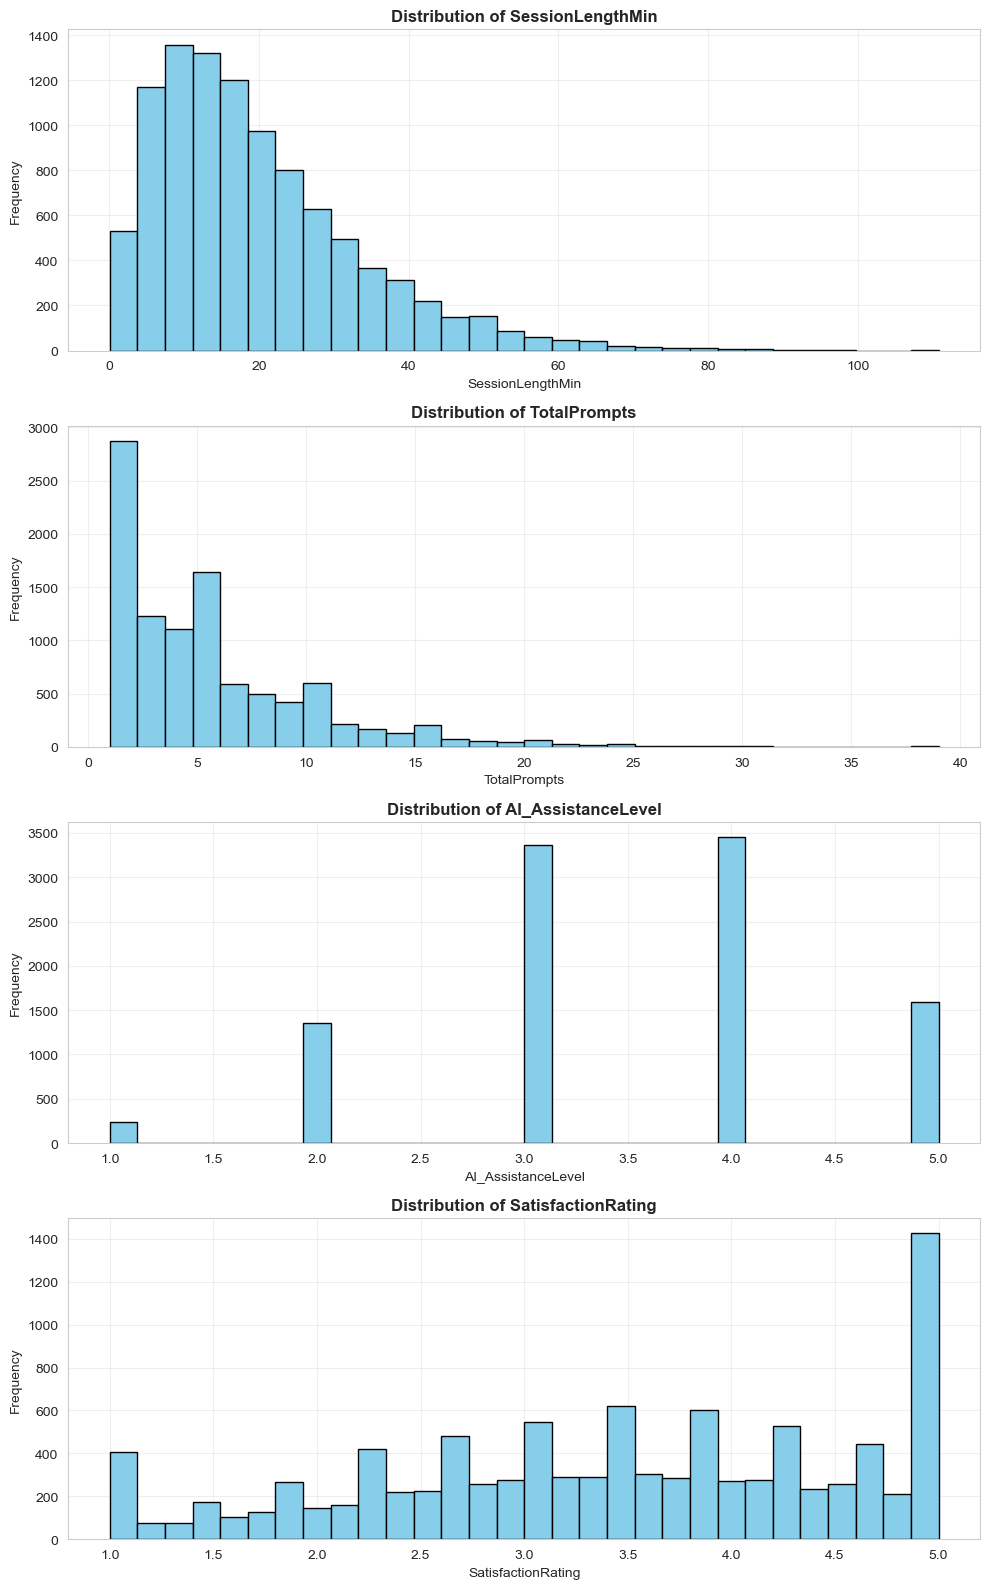

In [20]:
# Numeric Distributions

numeric_cols = df_student.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    df_student[col].hist(bins=30, ax=ax, edgecolor='black', color='skyblue')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation Matrix:
                    SessionLengthMin  TotalPrompts  AI_AssistanceLevel  \
SessionLengthMin            1.000000      0.902317           -0.006848   
TotalPrompts                0.902317      1.000000           -0.006355   
AI_AssistanceLevel         -0.006848     -0.006355            1.000000   
SatisfactionRating         -0.011136     -0.009561            0.775513   

                    SatisfactionRating  
SessionLengthMin             -0.011136  
TotalPrompts                 -0.009561  
AI_AssistanceLevel            0.775513  
SatisfactionRating            1.000000  


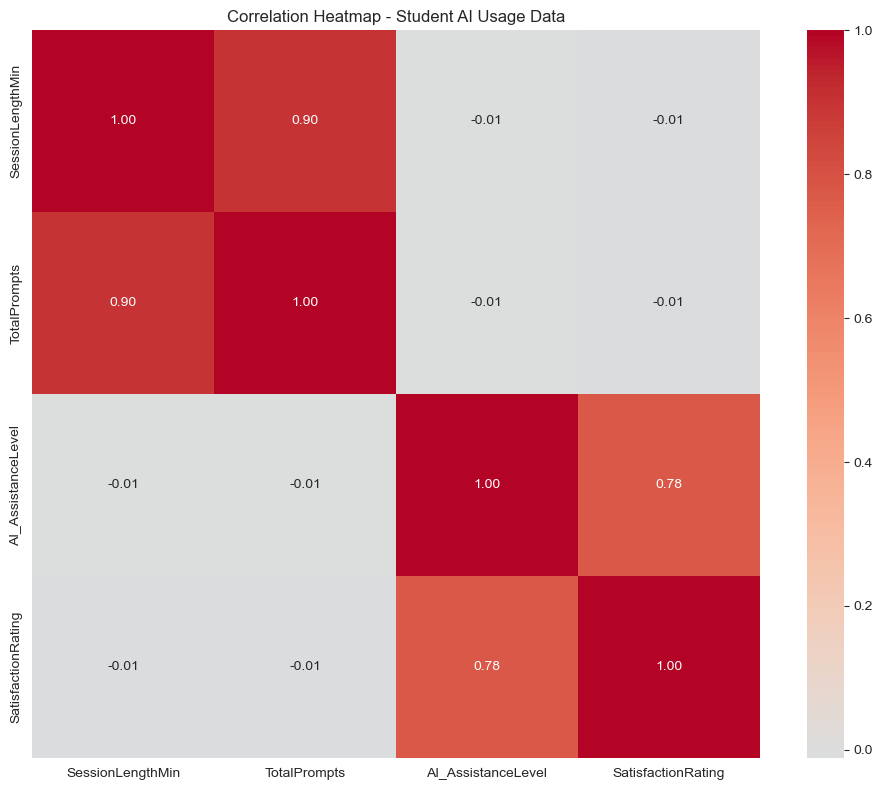

In [21]:
# Correlation Heatmap

numeric_cols = df_student.select_dtypes(include=[np.number]).columns
corr_matrix = df_student[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap - Student AI Usage Data')
plt.tight_layout()
plt.show()